# Stock Portfolio Risk & Return Analysis

### Question: Given a set of stocks across different sectors, what is the historical risk-return profile of each and what portfolio allocation would have minimized risk for an expected return over the past 5 year period?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)  #for reproducibility

returns = pd.read_csv("daily_returns.csv", index_col=0, parse_dates=True)

BENCHMARK = "SPY"
asset_returns = returns.drop(columns=[BENCHMARK])  # exclude benchmark from optimization
tickers = asset_returns.columns.tolist()
n_assets = len(tickers)

ann_return = asset_returns.mean() * 252
cov_matrix = asset_returns.cov() * 252  # annualized covariance matrix

print(f"Optimizing across {n_assets} assets: {tickers}")

Optimizing across 9 assets: ['AAPL', 'CVX', 'JNJ', 'KO', 'MSFT', 'NVDA', 'PG', 'UNH', 'XOM']


## Monte Carlo Simulation:
#### Generate 10,000 random portfolios by drawing random weights for each asset, then calculate each portfolio's expected annual return, volatility, and Sharpe ratio.

In [2]:
#Monte Carlo Simulation

n_portfolios = 10000

results = np.zeros((3, n_portfolios))
weights_record = []

for i in range(n_portfolios):
    weights = np.random.random(n_assets)
    weights /= np.sum(weights)
    weights_record.append(weights)

    port_return = np.dot(weights, ann_return)
    port_vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    port_sharpe = port_return / port_vol  # risk-free rate = 0, same simplification as Step 3

    results[0, i] = port_vol
    results[1, i] = port_return
    results[2, i] = port_sharpe

sim_results = pd.DataFrame(results.T, columns=["volatility", "return", "sharpe"])
sim_results.head()

,volatility,return,sharpe
0,0.206709,0.159869,0.773402
1,0.182752,0.177287,0.970094
2,0.202688,0.199856,0.986032
3,0.199797,0.145226,0.726869
4,0.209050,0.218801,1.046646


In [3]:
#Identify optimal portfolios

max_sharpe_idx = sim_results["sharpe"].idxmax()
min_vol_idx = sim_results["volatility"].idxmin()

max_sharpe_port = sim_results.loc[max_sharpe_idx]
min_vol_port = sim_results.loc[min_vol_idx]

max_sharpe_weights = weights_record[max_sharpe_idx]
min_vol_weights = weights_record[min_vol_idx]

print("Max-Sharpe portfolio:")
print(max_sharpe_port)
print("\nMin-volatility portfolio:")
print(min_vol_port)

Max-Sharpe portfolio:
volatility    0.240594
return        0.328814
sharpe        1.366675
Name: 1509, dtype: float64

Min-volatility portfolio:
volatility    0.171071
return        0.130318
sharpe        0.761773
Name: 4265, dtype: float64


Efficient Frontier - Each point is a randomly weighted portfolio coloured by its Sharpe ratio. The upper-left edge of the cloud — the point where you can't get more return without taking on more risk — is the efficient frontier. The two starred points mark the single best portfolio by each of two different criteria: highest risk-adjusted return (max Sharpe) and lowest absolute risk (min volatility).

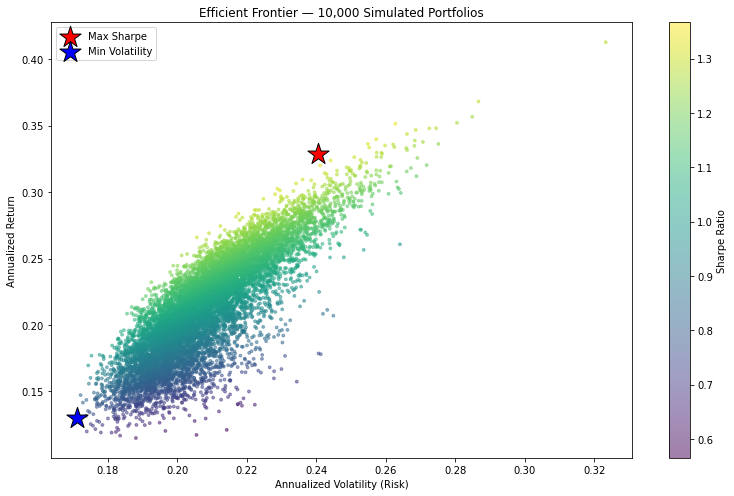

In [4]:
#Efficient Frontier Plot

fig, ax = plt.subplots(figsize=(11, 7))

scatter = ax.scatter(sim_results["volatility"], sim_results["return"],
                      c=sim_results["sharpe"], cmap="viridis",
                      s=8, alpha=0.5)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Sharpe Ratio")

# Mark max-Sharpe portfolio
ax.scatter(max_sharpe_port["volatility"], max_sharpe_port["return"],
           marker="*", color="red", s=500, edgecolor="black",
           linewidth=1, label="Max Sharpe", zorder=5)

# Mark min-volatility portfolio
ax.scatter(min_vol_port["volatility"], min_vol_port["return"],
           marker="*", color="blue", s=500, edgecolor="black",
           linewidth=1, label="Min Volatility", zorder=5)

ax.set_xlabel("Annualized Volatility (Risk)")
ax.set_ylabel("Annualized Return")
ax.set_title("Efficient Frontier — 10,000 Simulated Portfolios")
ax.legend(loc="upper left")
plt.tight_layout()
plt.savefig("fig_efficient_frontier.png", dpi=150)
plt.show()

## Optimal Portfolio Weights:
#### The table below shows the exact asset allocation for the max-Sharpe portfolio (Out of 10,000 tested, the one portfolio that produced the best return per unit of risk).

In [5]:
#Weights table

weights_table = pd.DataFrame({
    "ticker": tickers,
    "max_sharpe_weight": max_sharpe_weights,
    "min_vol_weight": min_vol_weights
}).sort_values("max_sharpe_weight", ascending=False).reset_index(drop=True)

weights_table["max_sharpe_weight"] = (weights_table["max_sharpe_weight"] * 100).round(2)
weights_table["min_vol_weight"] = (weights_table["min_vol_weight"] * 100).round(2)
weights_table.columns = ["Ticker", "Max Sharpe Weight (%)", "Min Vol Weight (%)"]

weights_table.to_csv("optimal_portfolio_weights.csv", index=False)
weights_table

,Ticker,Max Sharpe Weight (%),Min Vol Weight (%)
0,NVDA,33.94,0.39
1,JNJ,27.56,41.80
2,KO,10.62,19.13
3,XOM,8.53,16.24
4,CVX,7.34,0.03
5,PG,6.10,12.51
6,AAPL,4.79,8.74
7,MSFT,0.77,0.57
8,UNH,0.34,0.60


In [6]:
#Optimal portfolio summary stats

summary = pd.DataFrame({
    "Portfolio": ["Max Sharpe", "Min Volatility"],
    "Annualized Return (%)": [
        round(max_sharpe_port["return"] * 100, 2),
        round(min_vol_port["return"] * 100, 2)
    ],
    "Annualized Volatility (%)": [
        round(max_sharpe_port["volatility"] * 100, 2),
        round(min_vol_port["volatility"] * 100, 2)
    ],
    "Sharpe Ratio": [
        round(max_sharpe_port["sharpe"], 2),
        round(min_vol_port["sharpe"], 2)
    ]
})
summary.to_csv("optimal_portfolio_summary.csv", index=False)
summary

,Portfolio,Annualized Return (%),Annualized Volatility (%),Sharpe Ratio
0,Max Sharpe,32.88,24.06,1.37
1,Min Volatility,13.03,17.11,0.76


## Limitations:
#### 1. Weights are drawn to sum to 1 with no negatives, so short positions and cash allocation aren't modeled.
#### 2. Monte Carlo approximates the frontier but doesn't guarantee finding the exact mathematical optimum. `scipy.optimize.minimize` would converge to the precise frontier which would be the next step if this were a production tool rather than a portfolio piece.
#### 3. The covariance matrix is computed once over the full 2020–2025 window, but correlations between assets are not constant over time. A more advanced version would use rolling or shrinkage-estimated covariance.

## Findings:
#### The optimizer landed on NVDA and JNJ as the two biggest holdings in the max-Sharpe portfolio (33.9% and 27.6%), and the result is a Sharpe ratio of 1.37 which is better than either stock managed on its own back in Step 3. That's not a coincidence: NVDA and JNJ were barely correlated (0.08), so pairing them lets you keep NVDA's growth while JNJ quietly absorbs a lot of the bumpiness, something neither stock could pull off alone. The min-volatility portfolio tells a different but consistent story. It leans hard into defensive names, with JNJ, KO, XOM, and PG making up almost 90% of the mix, while NVDA and CVX are basically shut out (0.39% and 0.03%). CVX's exclusion is the more interesting case: on its own it looked decent, but because it moves almost in lockstep with XOM (0.86 correlation), the optimizer treats it as redundant risk rather than something that contributes to diversification.